In [538]:
# ============================================
# Week 4: Feature Importance & Ablation Study
# Student: Aylin Bozkurt
# Dataset: [winequality-red.csv]
# ============================================

In [539]:
# -------- IMPORTS --------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier # or your chosen model
from sklearn.feature_selection import (
mutual_info_classif,
RFE,
SelectKBest,
f_classif
)
from sklearn.metrics import *
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully.")

Libraries imported successfully.


In [540]:
# Set random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
# -------- CONFIGURATION --------
TEST_SIZE = 0.2
CV_FOLDS = 5
MODEL_PARAMS = {
# Your model parameters
'random_state': RANDOM_STATE
}
# -------- 1. LOAD DATA --------
print("\n" + "="*60)
print("1. LOAD DATA")
print("="*60)
df = pd.read_csv("data/winequality-red.csv")
print("Data loaded successfully.")



1. LOAD DATA
Data loaded successfully.


In [541]:
# -------- 2. EXPLORATORY ANALYSIS --------
print("\n" + "="*60)
print("2. EXPLORATORY ANALYSIS")
print("="*60)

# First look at the data
print("\n" + "-"*60)
print("\n2.1 FEATURE DESCRIPTION:")
print("\n" + "-"*60)
print(df.info())
print("\nFirst 5 rows of the dataset:")
display(df.head())


2. EXPLORATORY ANALYSIS

------------------------------------------------------------

2.1 FEATURE DESCRIPTION:

------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtyp

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [542]:
# Find missing values
# amount of missing values per column
print(df.isnull().sum())
# which columns have missing values
# when no missing values are found = False 
print(df.isnull().any())

print("\n" + "="*60)
print("FEATURE DESCRIPTION ✓")
print("="*60)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
fixed acidity           False
volatile acidity        False
citric acid             False
residual sugar          False
chlorides               False
free sulfur dioxide     False
total sulfur dioxide    False
density                 False
pH                      False
sulphates               False
alcohol                 False
quality                 False
dtype: bool

FEATURE DESCRIPTION ✓


In [543]:
print("\n" + "-"*60) 
print("2.2 CORRELATION ANALYSIS")
print("-"*60)
# Géron Chapter 2: "Chapter 2. End-to-End Machine Learning Project" - Looking for Correlations
# standard correlation coefficient (also called Pearson's r)



------------------------------------------------------------
2.2 CORRELATION ANALYSIS
------------------------------------------------------------



1. Correlation with Target (Quality):
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

2. Top 5 Features Most Correlated with Quality:
   - alcohol: 0.4762
   - sulphates: 0.2514
   - citric acid: 0.2264
   - fixed acidity: 0.1241
   - residual sugar: 0.0137

3. Bottom 5 Features Least Correlated with Quality:
   - pH: -0.0577
   - chlorides: -0.1289
   - density: -0.1749
   - total sulfur dioxide: -0.1851
   - volatile acidity: -0.3906

------------------------------------------------------------
Creating FIGURE 1: Correlation Matrix Heatmap
------------------------------------------------------------
✓ Figure 1 

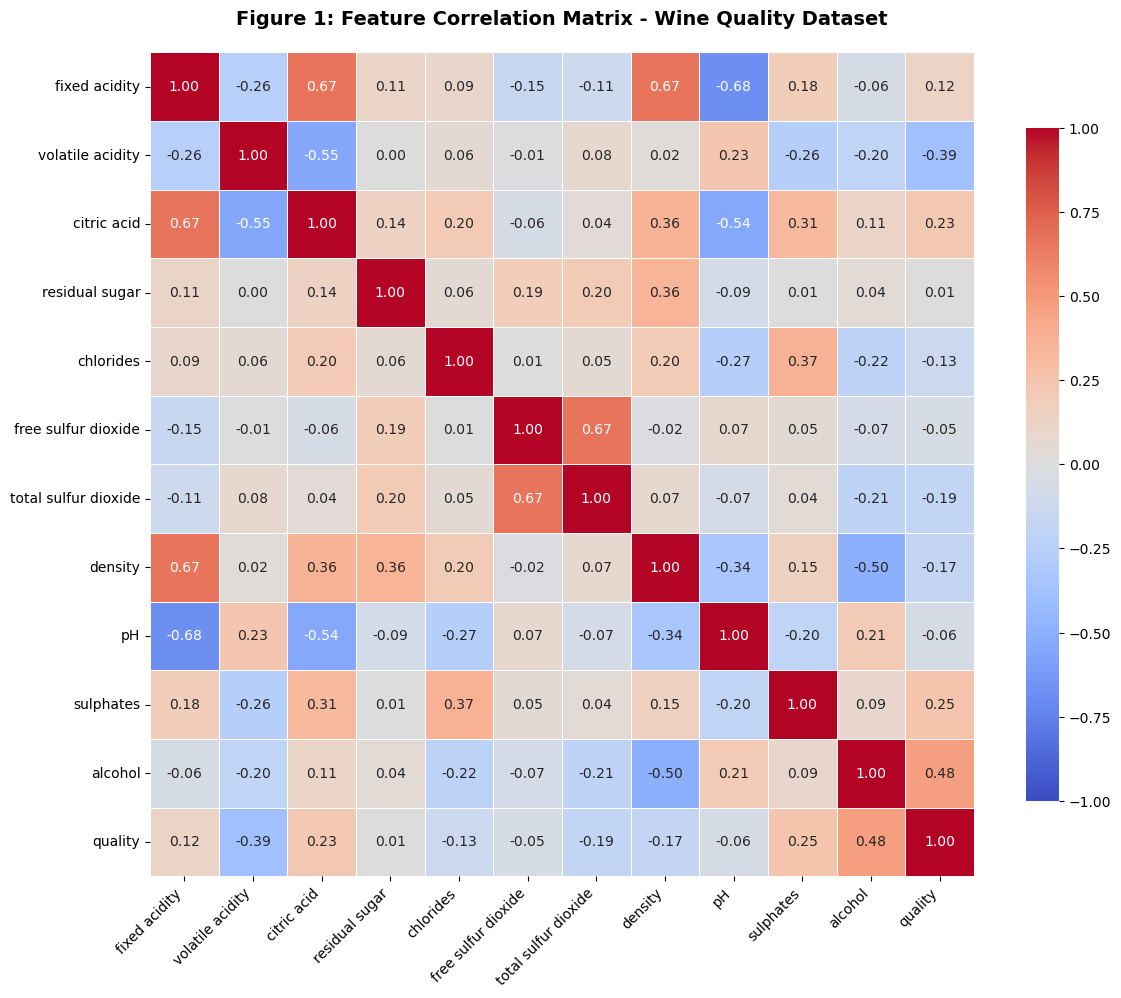


------------------------------------------------------------
Creating Additional Visualization: Feature-Target Correlation
------------------------------------------------------------
✓ Additional visualization saved as 'feature_target_correlation.png'
  Green bars = positive correlation with quality
  Red bars = negative correlation with quality


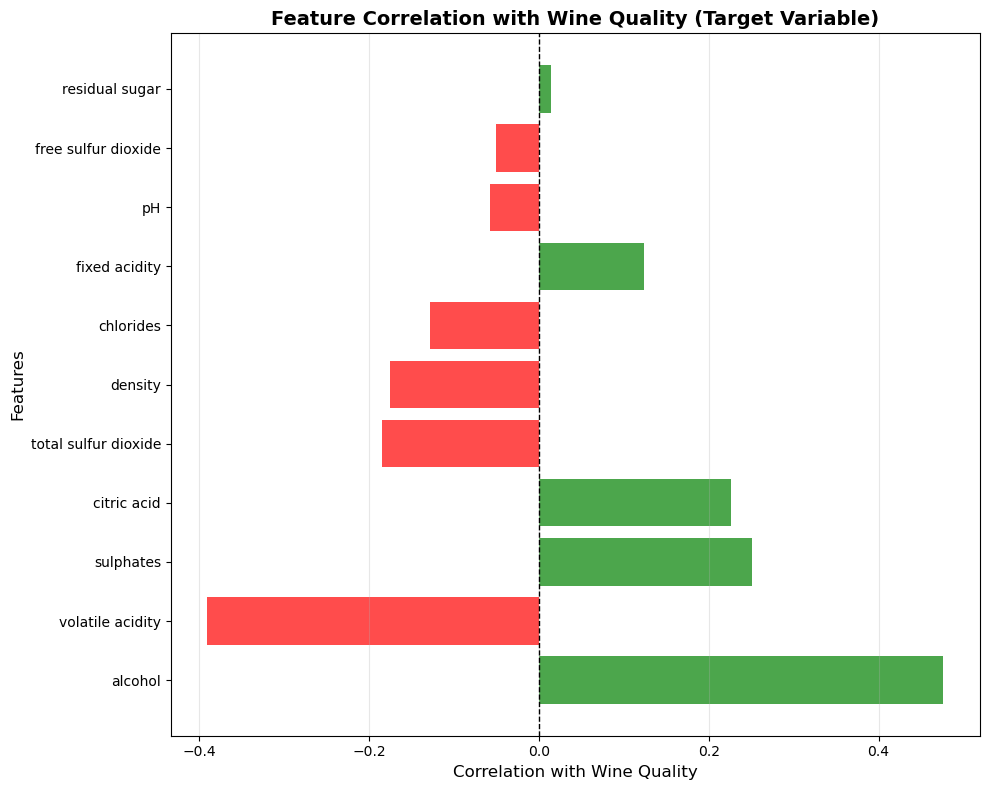


------------------------------------------------------------
Creating Scatter Matrix (Géron Method)
------------------------------------------------------------
Selected attributes for scatter matrix: ['quality', 'alcohol', 'sulphates', 'citric acid']
✓ Scatter matrix saved as 'scatter_matrix_geron.png'
  Diagonal: Histograms showing feature distributions
  Off-diagonal: Scatter plots showing feature relationships


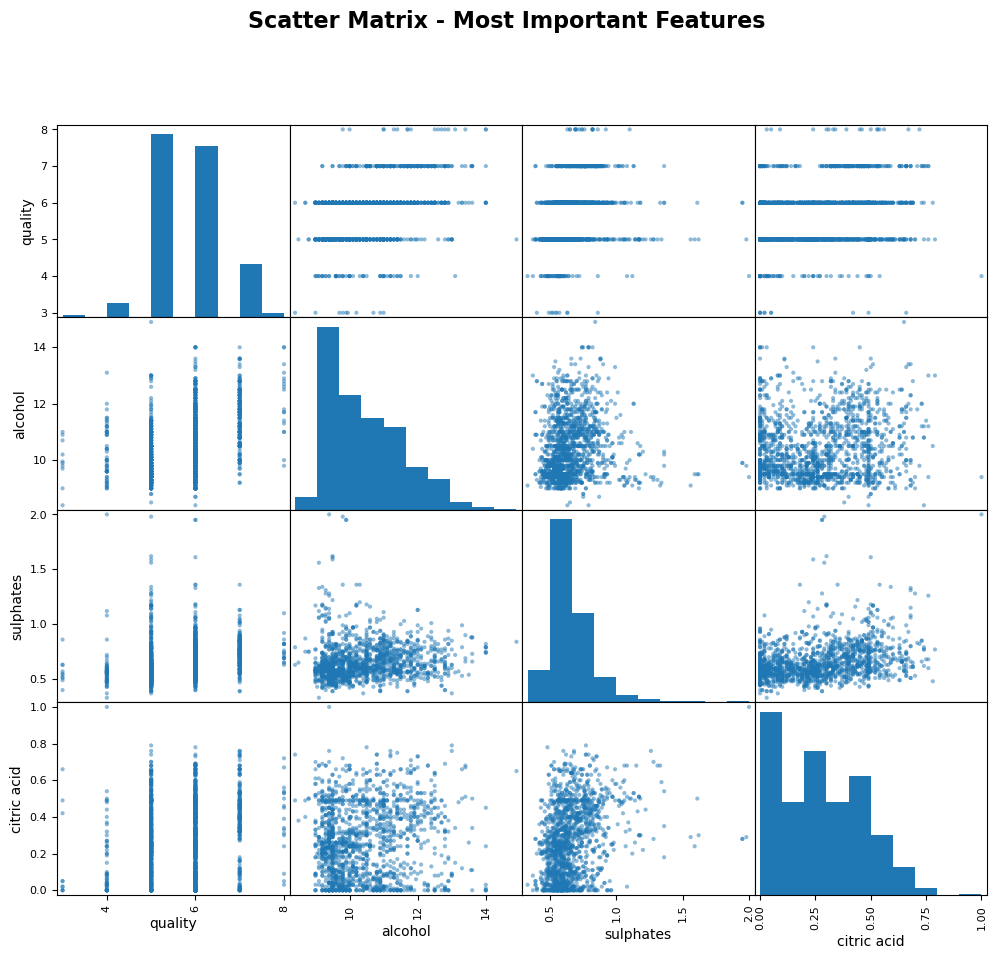


4. Highly Correlated Feature Pairs (potential multicollinearity):
   (Features with correlation > 0.7 or < -0.7)
   No highly correlated feature pairs found (threshold = 0.7)

------------------------------------------------------------
CORRELATION ANALYSIS COMPLETED ✓
------------------------------------------------------------

KEY INSIGHTS:
- Most positively correlated with quality: alcohol (0.476)
- Most negatively correlated with quality: volatile acidity (-0.391)
- No strong multicollinearity detected between features


In [544]:
# ========== 1. COMPUTE CORRELATION MATRIX ==========
correlation_matrix = df.corr()  # Computes Pearson's r for all feature pairs
# Correlation Coefficient (r):
# - r = 1: Perfect positive correlation (when X increases, Y increases)
# - r = 0: No correlation (X and Y are independent)
# - r = -1: Perfect negative correlation (when X increases, Y decreases)
# Example: alcohol and quality have r≈0.48 (positively correlated)

# ========== 2. CORRELATION WITH TARGET ==========
# Check correlation of each feature with the target variable 'quality'
print("\n1. Correlation with Target (Quality):")
target_correlation = correlation_matrix['quality'].sort_values(ascending=False)
# Takes ONLY the 'quality' column from the Correlation Matrix
# .sort_values(ascending=False) sorts from HIGHEST to LOWEST correlation
print(target_correlation)
# Interpretation:
# - Positive values: Feature increases → Quality increases (e.g., alcohol)
# - Negative values: Feature increases → Quality decreases (e.g., volatile acidity)
# - Close to 0: Little to no linear relationship

# ========== 3. TOP 5 POSITIVELY CORRELATED ==========
print("\n2. Top 5 Features Most Correlated with Quality:")
top_correlations = target_correlation.drop('quality').head(5)
# .drop('quality') removes quality itself (always has r=1.0 with itself)
# .head(5) takes the first 5 entries (highest correlations)
for feature, corr in top_correlations.items():  # Iterate through feature name and correlation value
    print(f"   - {feature}: {corr:.4f}")  # .4f means: 4 decimal places

# ========== 4. TOP 5 NEGATIVELY CORRELATED ==========
print("\n3. Bottom 5 Features Least Correlated with Quality:")
bottom_correlations = target_correlation.drop('quality').tail(5)
# .tail(5) takes the last 5 entries (lowest/most negative correlations)
for feature, corr in bottom_correlations.items():
    print(f"   - {feature}: {corr:.4f}")

# ==========================================
# FIGURE 1: CORRELATION MATRIX HEATMAP
# ==========================================
# Géron uses scatter_matrix, but heatmap is better for papers
print("\n" + "-"*60)
print("Creating FIGURE 1: Correlation Matrix Heatmap")
print("-"*60)

plt.figure(figsize=(12, 10))  # Large figure (12x10 inches) because we have 12x12 matrix
sns.heatmap(correlation_matrix,  # The Correlation Matrix as heatmap
            annot=True,          # annot=True shows correlation values INSIDE the cells
            fmt='.2f',           # Format: 2 decimal places (e.g., 0.48 instead of 0.476543)
            cmap='coolwarm',     # Color scheme: Blue (negative) → White (0) → Red (positive)
            square=True,         # Make cells square-shaped (not rectangular)
            linewidths=0.5,      # 0.5 pixel wide lines between cells (better readability)
            cbar_kws={"shrink": 0.8},  # Colorbar 80% of figure height
            center=0,            # Center color scale at 0 (White = no correlation)
            vmin=-1, vmax=1)     # Min/Max values: -1 to +1 (Full range of Pearson's r)

# Formatting for better readability
plt.title('Figure 1: Feature Correlation Matrix - Wine Quality Dataset', 
          fontsize=14, fontweight='bold', pad=20)  # pad=20 adds space to the plot
plt.xticks(rotation=45, ha='right')  # X-axis labels rotated 45°, right-aligned
plt.yticks(rotation=0)  # Y-axis labels horizontal (0° rotation)
plt.tight_layout()  # Automatic layout (prevents cut-off labels)
plt.savefig('plots/01_exploratory/figure1_correlation_matrix.png', dpi=300, bbox_inches='tight')  # Save
# dpi=300 = high resolution for paper
# bbox_inches='tight' = crop white margins
print("✓ Figure 1 saved as 'figure1_correlation_matrix.png'")
print("  This figure shows correlations between all features.")
print("  - Red colors = positive correlation")
print("  - Blue colors = negative correlation")
print("  - The darker the color, the stronger the correlation")
plt.show()

# ==========================================
# ADDITIONAL: BAR CHART (like Géron's approach)
# ==========================================
print("\n" + "-"*60)
print("Creating Additional Visualization: Feature-Target Correlation")
print("-"*60)

plt.figure(figsize=(10, 8))  # New figure
# Sort features by ABSOLUTE correlation (|r|, ignores sign)
feature_target_corr = target_correlation.drop('quality').sort_values(key=abs, ascending=False)
# key=abs means: sort by absolute value
# ascending=False: highest |r| first

# Color based on sign: Green = positive, Red = negative
colors = ['green' if x > 0 else 'red' for x in feature_target_corr]
# List comprehension: for each value x, if x>0 then 'green', else 'red'

plt.barh(feature_target_corr.index, feature_target_corr.values, color=colors, alpha=0.7)
# .barh = horizontal bar chart (better for long feature names)
# .index = Feature names (Y-axis)
# .values = Correlation values (X-axis)
# alpha=0.7 = 70% opacity (slightly transparent)

plt.xlabel('Correlation with Wine Quality', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Correlation with Wine Quality (Target Variable)', 
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)  # Vertical line at x=0
# axvline = "axis vertical line"
# Helps to see which features are positively/negatively correlated
plt.grid(axis='x', alpha=0.3)  # Vertical grid lines (only X-axis), 30% transparent
plt.tight_layout()
plt.savefig('plots/01_exploratory/feature_target_correlation.png', dpi=300, bbox_inches='tight')
print("✓ Additional visualization saved as 'feature_target_correlation.png'")
print("  Green bars = positive correlation with quality")
print("  Red bars = negative correlation with quality")
plt.show()

# ==========================================
# SCATTER MATRIX (like in Géron's book!)
# ==========================================
# Géron: "Another way to check for correlation between attributes is to use
#         the pandas scatter_matrix() function"
print("\n" + "-"*60)
print("Creating Scatter Matrix (Géron Method)")
print("-"*60)

from pandas.plotting import scatter_matrix  # Import the scatter_matrix function

# Select the most important features for Scatter Matrix
# Géron: "let's just focus on a few promising attributes that seem most correlated"
# We take: quality (target) + top 3 correlated features
attributes = ['quality', 
              target_correlation.drop('quality').index[0],  # Top 1 Feature
              target_correlation.drop('quality').index[1],  # Top 2 Feature
              target_correlation.drop('quality').index[2]]  # Top 3 Feature

print(f"Selected attributes for scatter matrix: {attributes}")

# Create Scatter Matrix
scatter_matrix(df[attributes], figsize=(12, 10), diagonal='hist', alpha=0.5)
# df[attributes] = only the selected columns
# figsize=(12,10) = size of the figure
# diagonal='hist' = diagonal shows histograms (not scatter against itself)
# alpha=0.5 = 50% transparent (better visibility with many points)

# What does Scatter Matrix show?
# - Diagonal: Histogram of each feature (distribution)
# - Off-diagonal: Scatter plots between feature pairs
# - Helps visually identify correlations (linear relationships = points form a line)

plt.suptitle('Scatter Matrix - Most Important Features', fontsize=16, fontweight='bold', y=0.995)
# suptitle = "super title" for entire figure (above all subplots)
# y=0.995 positions title at the very top
plt.savefig('plots/01_exploratory/scatter_matrix_geron.png', dpi=300, bbox_inches='tight')
print("✓ Scatter matrix saved as 'scatter_matrix_geron.png'")
print("  Diagonal: Histograms showing feature distributions")
print("  Off-diagonal: Scatter plots showing feature relationships")
plt.show()

# ==========================================
# MULTICOLLINEARITY CHECK
# ==========================================
# Géron doesn't mention this explicitly, but it's important for Feature Selection
print("\n4. Highly Correlated Feature Pairs (potential multicollinearity):")
print("   (Features with correlation > 0.7 or < -0.7)")

threshold = 0.7  # Threshold for "high correlation"
# In literature: |r| > 0.7 is often considered "strongly correlated"
high_corr_pairs = []  # Empty list to store the pairs

# Iterate through all feature pairs
for i in range(len(correlation_matrix.columns)):  # Row index
    for j in range(i+1, len(correlation_matrix.columns)):  # Column index (only upper triangle matrix)
        # i+1 prevents duplicates (A-B and B-A) and self-correlation (A-A)
        if abs(correlation_matrix.iloc[i, j]) > threshold:  # abs() = absolute value
            # .iloc[i,j] = value at position (row i, column j)
            feature1 = correlation_matrix.columns[i]  # Name of Feature 1
            feature2 = correlation_matrix.columns[j]  # Name of Feature 2
            corr_value = correlation_matrix.iloc[i, j]  # Correlation value
            high_corr_pairs.append((feature1, feature2, corr_value))  # Store as tuple
            print(f"   - {feature1} <-> {feature2}: {corr_value:.4f}")
            # Interpretation: These features are redundant (provide similar information)

# If no highly correlated pairs found
if not high_corr_pairs:  # not high_corr_pairs = list is empty
    print("   No highly correlated feature pairs found (threshold = 0.7)")

# ==========================================
# SUMMARY
# ==========================================
print("\n" + "-"*60)
print("CORRELATION ANALYSIS COMPLETED ✓")
print("-"*60)
print("\nKEY INSIGHTS:")
# Reminder: Put these insights in our paper
print(f"- Most positively correlated with quality: {target_correlation.drop('quality').idxmax()} ({target_correlation.drop('quality').max():.3f})")
# .idxmax() returns the INDEX (feature name) of the maximum value
# .max() returns the maximum value itself
print(f"- Most negatively correlated with quality: {target_correlation.drop('quality').idxmin()} ({target_correlation.drop('quality').min():.3f})")
# .idxmin() and .min() for minimum
if high_corr_pairs:
    print(f"- Found {len(high_corr_pairs)} highly correlated feature pairs (may indicate redundancy)")
else:
    print("- No strong multicollinearity detected between features")


In [545]:

# Feature descriptions
# Correlation analysis
# Distribution plots


------------------------------------------------------------
2.3 DISTRIBUTION PLOTS
------------------------------------------------------------

Creating histograms for all features...
✓ Feature distribution plots saved as 'feature_distributions.png'
  Use this to identify:
  - Skewed distributions (most values on one side)
  - Normal/Gaussian distributions (bell curve)
  - Outliers (bars far from the main distribution)


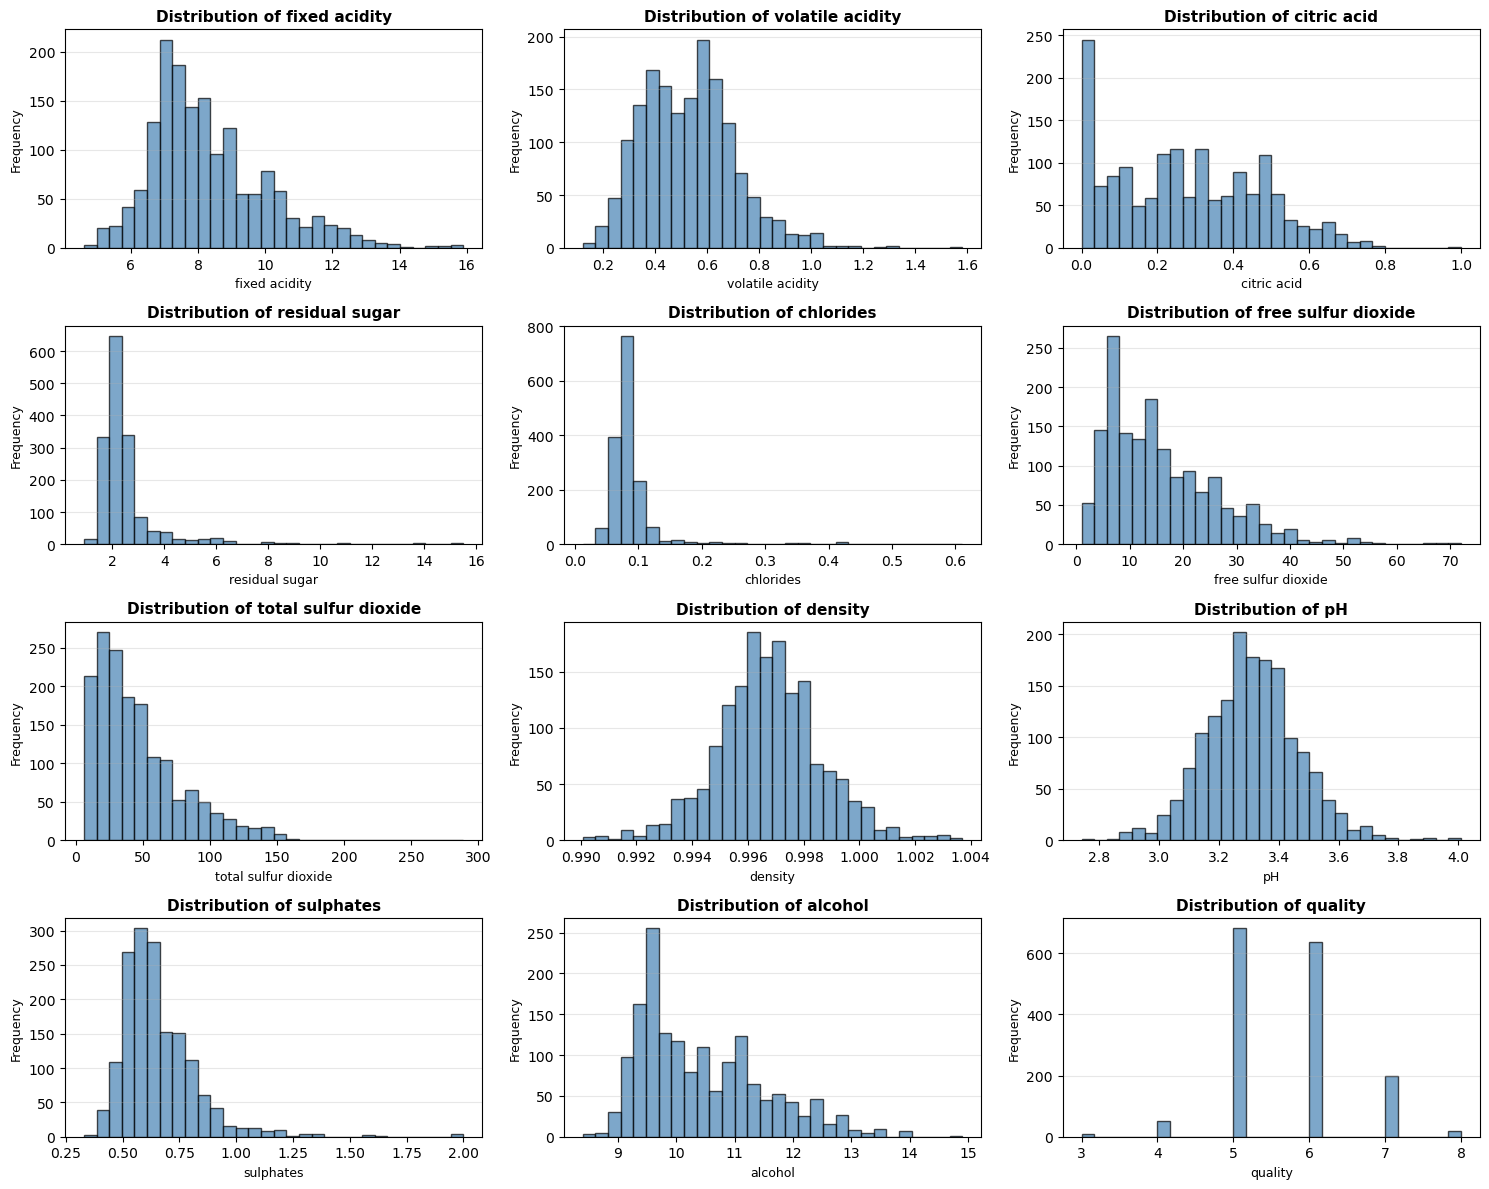


Creating box plots for outlier detection...
✓ Box plots saved as 'feature_boxplots.png'
  Red dots = outliers (values beyond 1.5*IQR from Q1/Q3)
  Red line in box = median value


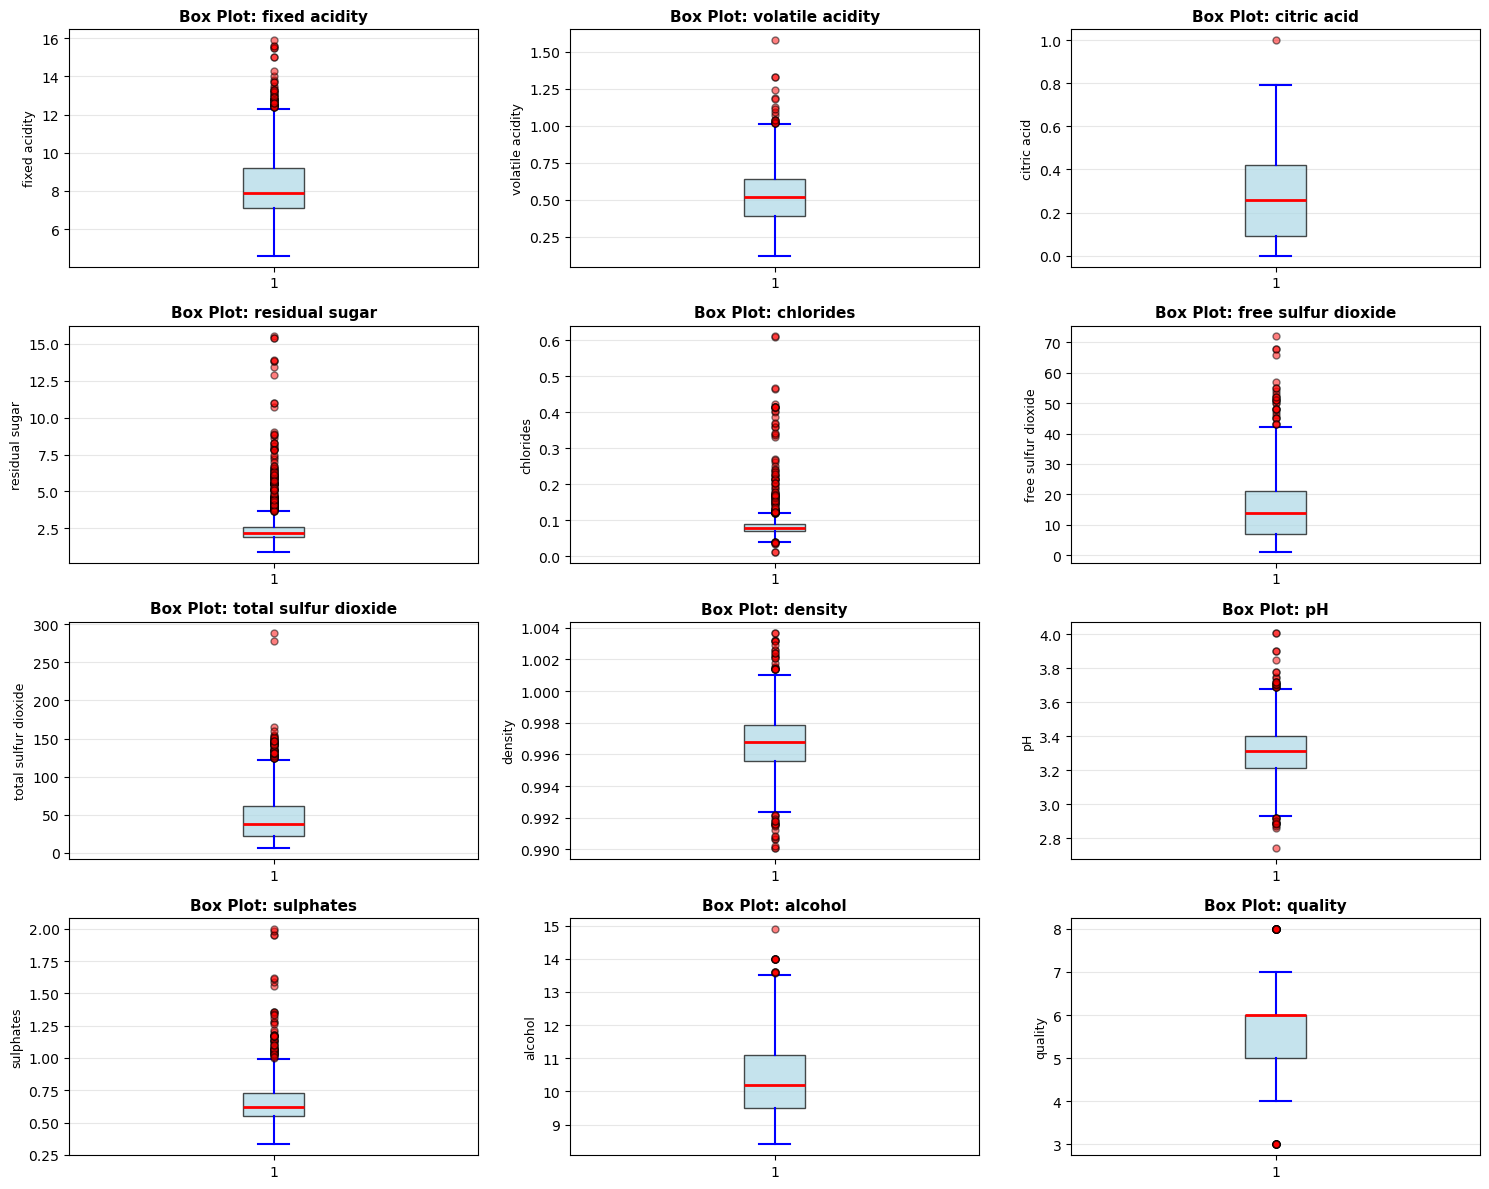


Calculating distribution statistics...

Distribution Statistics Table:
                                   Feature    Mean  Median     Std    Min  \
fixed acidity                fixed acidity   8.320   7.900   1.741  4.600   
volatile acidity          volatile acidity   0.528   0.520   0.179  0.120   
citric acid                    citric acid   0.271   0.260   0.195  0.000   
residual sugar              residual sugar   2.539   2.200   1.410  0.900   
chlorides                        chlorides   0.087   0.079   0.047  0.012   
free sulfur dioxide    free sulfur dioxide  15.875  14.000  10.460  1.000   
total sulfur dioxide  total sulfur dioxide  46.468  38.000  32.895  6.000   
density                            density   0.997   0.997   0.002  0.990   
pH                                      pH   3.311   3.310   0.154  2.740   
sulphates                        sulphates   0.658   0.620   0.170  0.330   
alcohol                            alcohol  10.423  10.200   1.066  8.400   
qual

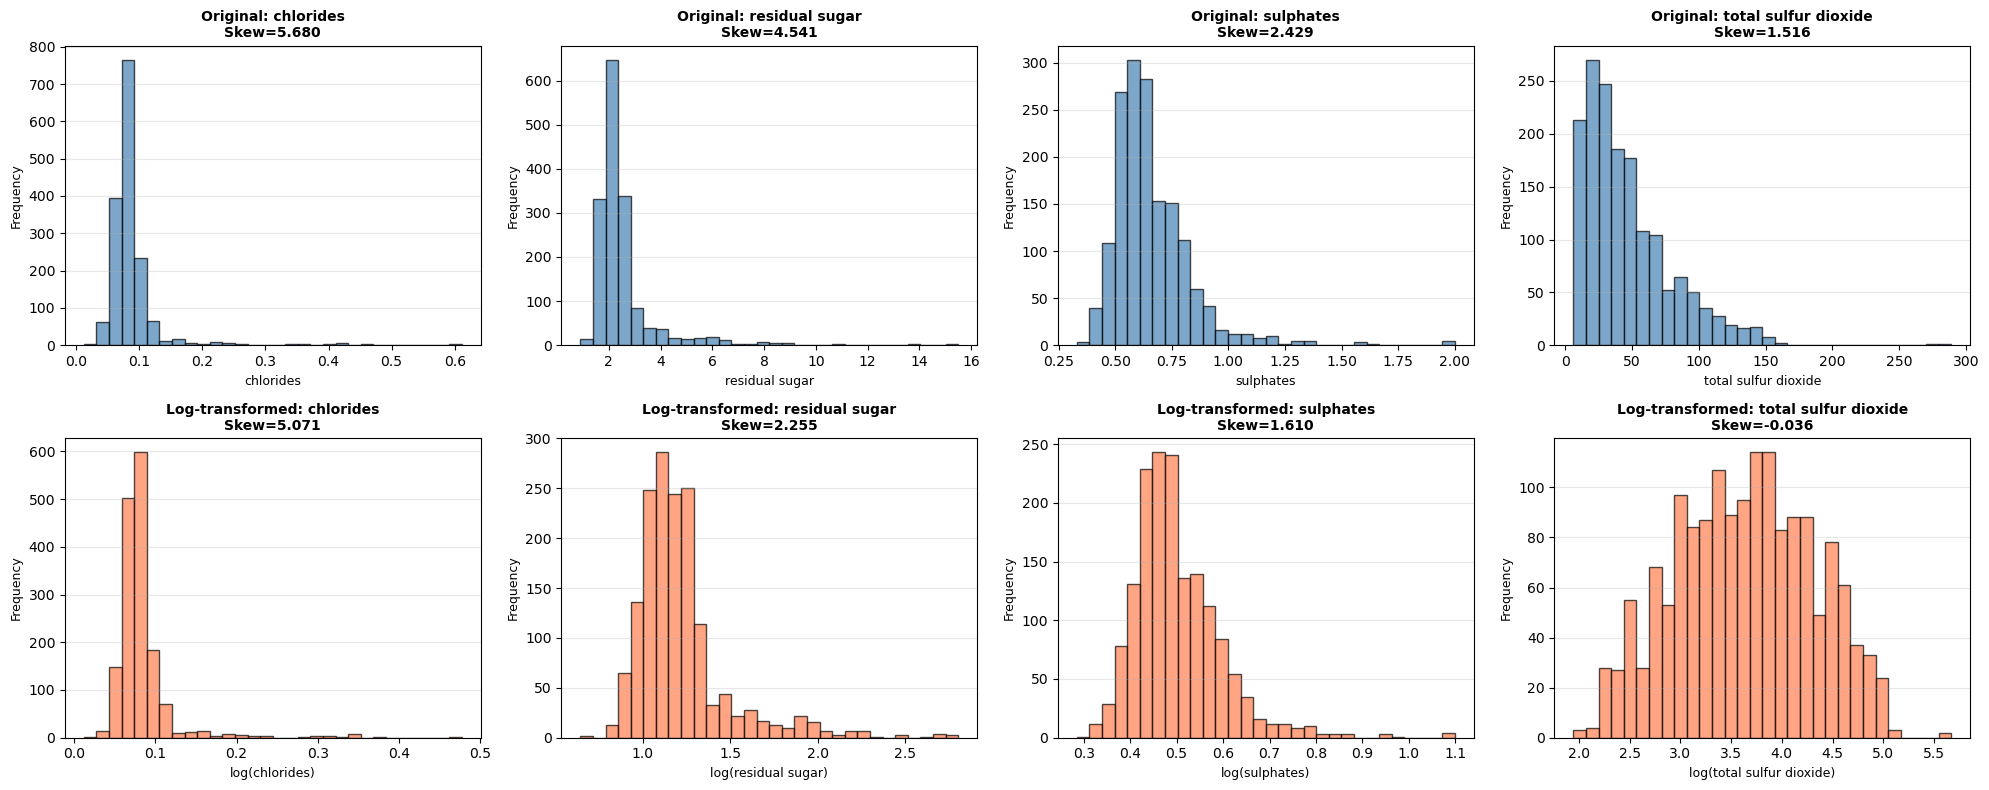


Creating KDE plots for all features...
✓ KDE plots saved as 'feature_kde_plots.png'
  Smooth curves show probability density
  Red dashed line = mean value


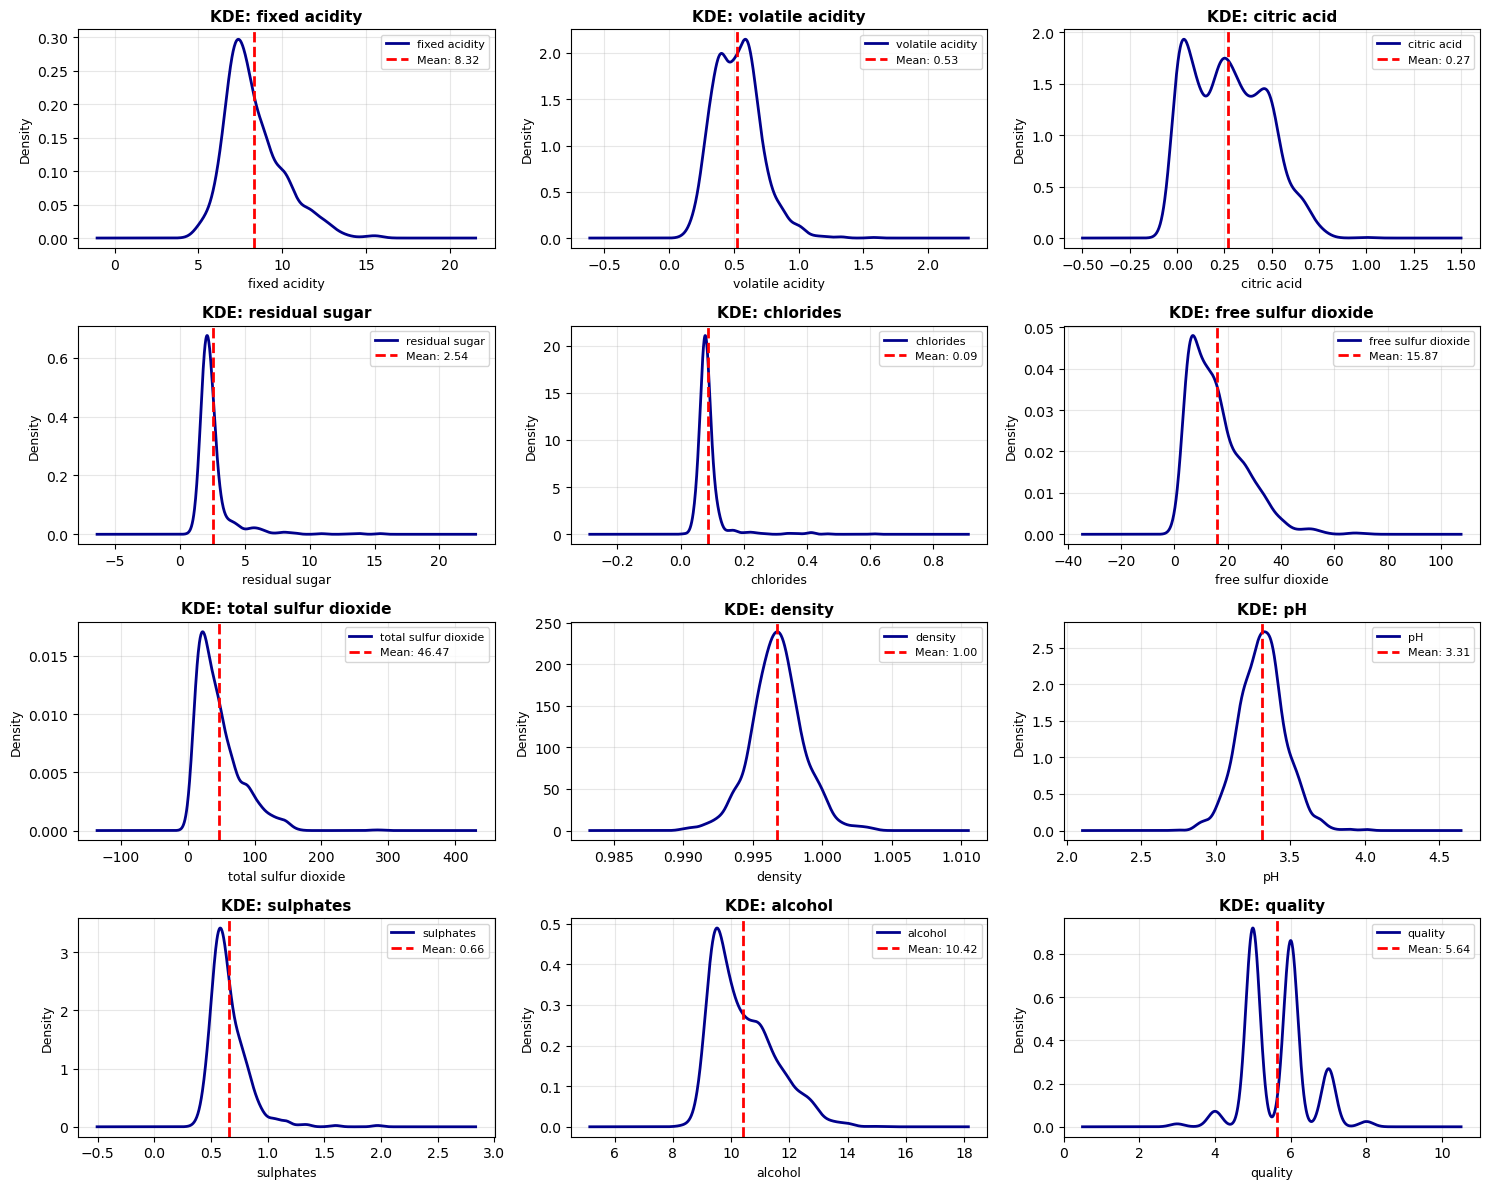


------------------------------------------------------------
DISTRIBUTION ANALYSIS COMPLETED ✓
------------------------------------------------------------

KEY INSIGHTS:
- Total features analyzed: 12
- Skewed features (|skew| > 0.5): 8
- Most skewed feature: chlorides (skew=5.680)

Outlier Summary:
  - fixed acidity: 49 outliers (3.1%)
  - volatile acidity: 19 outliers (1.2%)
  - citric acid: 1 outliers (0.1%)
  - residual sugar: 155 outliers (9.7%)
  - chlorides: 112 outliers (7.0%)
  - free sulfur dioxide: 30 outliers (1.9%)
  - total sulfur dioxide: 55 outliers (3.4%)
  - density: 45 outliers (2.8%)
  - pH: 35 outliers (2.2%)
  - sulphates: 59 outliers (3.7%)
  - alcohol: 13 outliers (0.8%)
  - quality: 28 outliers (1.8%)

Files Created:
  ✓ feature_distributions.png - Histograms of all features
  ✓ feature_boxplots.png - Box plots for outlier detection
  ✓ feature_kde_plots.png - Kernel Density Estimates
  ✓ distribution_statistics.csv - Statistical summary table
  ✓ skewed_featu

In [546]:
# ==========================================
# DISTRIBUTION PLOTS
# ==========================================
# Géron: "Visualizing data is one of the most important tasks in data exploration"
# Distribution plots help us understand:
# - Are features normally distributed? (important for some ML algorithms)
# - Are there outliers? (extreme values that might affect model)
# - What's the range and spread of each feature?
# - Are features on different scales? (important for scaling decision)

print("\n" + "-"*60) 
print("2.3 DISTRIBUTION PLOTS")
print("-"*60)

# ========== 1. HISTOGRAMS FOR ALL FEATURES ==========
# Histogram shows how values are distributed across bins (ranges)
# Géron: "The hist() method plots a histogram for each numerical attribute"

print("\nCreating histograms for all features...")

# Create a grid of subplots: 4 rows x 3 columns = 12 plots (11 features + 1 target)
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
# subplots(4, 3) creates a 4x3 grid of plots
# figsize=(15, 12) makes the entire figure 15 inches wide, 12 inches tall
axes = axes.ravel()  # Flatten the 2D array of axes into 1D array for easier iteration
# .ravel() converts [[ax1, ax2, ax3], [ax4, ax5, ax6], ...] to [ax1, ax2, ax3, ax4, ...]

# Plot histogram for each feature
for idx, col in enumerate(df.columns):  # enumerate gives us both index and column name
    # idx = index (0, 1, 2, ...), col = column name ('fixed acidity', 'volatile acidity', ...)
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    # .hist() creates histogram
    # bins=30 divides the data range into 30 bins/buckets
    # edgecolor='black' adds black borders around bars (better visibility)
    # alpha=0.7 = 70% opacity (slightly transparent)
    # color='steelblue' makes bars blue
    
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    # Title for each subplot
    axes[idx].set_xlabel(col, fontsize=9)  # X-axis label
    axes[idx].set_ylabel('Frequency', fontsize=9)  # Y-axis label (count of samples)
    axes[idx].grid(axis='y', alpha=0.3)  # Add horizontal grid lines, 30% transparent

# Hide the last subplot if we have an odd number of features
# (We have 12 features total, so all subplots are used)
if len(df.columns) < len(axes):  # If features < subplots
    for idx in range(len(df.columns), len(axes)):  # Hide unused subplots
        axes[idx].set_visible(False)

plt.tight_layout()  # Adjust spacing to prevent overlapping labels
plt.savefig('plots/01_exploratory/feature_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Feature distribution plots saved as 'feature_distributions.png'")
print("  Use this to identify:")
print("  - Skewed distributions (most values on one side)")
print("  - Normal/Gaussian distributions (bell curve)")
print("  - Outliers (bars far from the main distribution)")
plt.show()

# ========== 2. BOX PLOTS FOR OUTLIER DETECTION ==========
# Box plots (also called box-and-whisker plots) show:
# - Median (middle line in box)
# - Q1 and Q3 (box edges = 25th and 75th percentiles)
# - IQR (Interquartile Range = Q3 - Q1)
# - Outliers (points beyond whiskers)
# Géron mentions outliers: "You may want to remove outliers or cap them"

print("\nCreating box plots for outlier detection...")

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(df.columns):
    axes[idx].boxplot(df[col], vert=True, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', alpha=0.7),
                      medianprops=dict(color='red', linewidth=2),
                      whiskerprops=dict(color='blue', linewidth=1.5),
                      capprops=dict(color='blue', linewidth=1.5),
                      flierprops=dict(marker='o', markerfacecolor='red', 
                                     markersize=5, alpha=0.5))
    # .boxplot() creates box-and-whisker plot
    # vert=True makes it vertical
    # patch_artist=True allows us to color the box
    # boxprops sets box appearance (light blue, 70% opacity)
    # medianprops sets median line (red, thick)
    # whiskerprops sets whisker lines (blue)
    # capprops sets cap lines at whisker ends
    # flierprops sets outlier point appearance (red circles)
    
    axes[idx].set_title(f'Box Plot: {col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(col, fontsize=9)
    axes[idx].grid(axis='y', alpha=0.3)

# Hide unused subplots
if len(df.columns) < len(axes):
    for idx in range(len(df.columns), len(axes)):
        axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('plots/01_exploratory/feature_boxplots.png', dpi=300, bbox_inches='tight')
print("✓ Box plots saved as 'feature_boxplots.png'")
print("  Red dots = outliers (values beyond 1.5*IQR from Q1/Q3)")
print("  Red line in box = median value")
plt.show()

# ========== 3. DISTRIBUTION STATISTICS SUMMARY ==========
# Calculate skewness and kurtosis for each feature
# - Skewness: measures asymmetry of distribution
#   * Skew = 0: symmetric (normal distribution)
#   * Skew > 0: right-skewed (long tail on right)
#   * Skew < 0: left-skewed (long tail on left)
# - Kurtosis: measures "tailedness" (how much data in tails vs. center)
#   * Kurtosis = 0: normal distribution
#   * Kurtosis > 0: heavy tails (more outliers)
#   * Kurtosis < 0: light tails (fewer outliers)

print("\nCalculating distribution statistics...")

from scipy import stats  # Import scipy for skewness and kurtosis

distribution_stats = pd.DataFrame({
    'Feature': df.columns,
    'Mean': df.mean(),
    'Median': df.median(),
    'Std': df.std(),
    'Min': df.min(),
    'Max': df.max(),
    'Skewness': df.skew(),  # .skew() calculates skewness
    'Kurtosis': df.kurtosis()  # .kurtosis() calculates kurtosis
})

print("\nDistribution Statistics Table:")
print(distribution_stats.round(3))  # Round to 3 decimal places
distribution_stats.to_csv('results/distribution_statistics.csv', index=False)
print("\n✓ Distribution statistics saved as 'distribution_statistics.csv'")

# ========== 4. IDENTIFY SKEWED FEATURES ==========
# Features with |skewness| > 0.5 are considered moderately skewed
# Features with |skewness| > 1.0 are considered highly skewed
# Skewed features might need transformation (log, sqrt, Box-Cox)

print("\n" + "="*60)
print("SKEWNESS ANALYSIS")
print("="*60)

skewed_features = distribution_stats[abs(distribution_stats['Skewness']) > 0.5].sort_values('Skewness', key=abs, ascending=False)
# abs(Skewness) > 0.5 filters features with moderate to high skewness
# sort_values by absolute skewness descending

if len(skewed_features) > 0:
    print(f"\nFound {len(skewed_features)} skewed features (|skewness| > 0.5):")
    for _, row in skewed_features.iterrows():  # Iterate through each row
        skew_val = row['Skewness']
        skew_type = "right-skewed" if skew_val > 0 else "left-skewed"
        print(f"  - {row['Feature']}: {skew_val:.3f} ({skew_type})")
    
    print("\nNote: Skewed features may benefit from transformations:")
    print("  - Right-skewed (positive): log transform, sqrt transform")
    print("  - Left-skewed (negative): square transform, exponential transform")
else:
    print("\nNo highly skewed features detected (all |skewness| < 0.5)")

# ========== 5. VISUALIZE SKEWED FEATURES (if any) ==========
if len(skewed_features) > 0:
    print("\nCreating comparison plots for most skewed features...")
    
    # Take top 4 most skewed features (or fewer if less than 4)
    top_skewed = skewed_features.head(min(4, len(skewed_features)))
    
    fig, axes = plt.subplots(2, len(top_skewed), figsize=(5*len(top_skewed), 8))
    # Create 2 rows: original distribution (top) and log-transformed (bottom)
    
    if len(top_skewed) == 1:  # If only 1 feature, axes is 1D array
        axes = axes.reshape(-1, 1)  # Make it 2D array for consistent indexing
    
    for idx, (_, row) in enumerate(top_skewed.iterrows()):
        feature = row['Feature']
        
        # Top row: Original distribution
        axes[0, idx].hist(df[feature], bins=30, color='steelblue', 
                         edgecolor='black', alpha=0.7)
        axes[0, idx].set_title(f'Original: {feature}\nSkew={row["Skewness"]:.3f}', 
                              fontsize=10, fontweight='bold')
        axes[0, idx].set_xlabel(feature, fontsize=9)
        axes[0, idx].set_ylabel('Frequency', fontsize=9)
        axes[0, idx].grid(axis='y', alpha=0.3)
        
        # Bottom row: Log-transformed distribution (if all values are positive)
        if df[feature].min() > 0:  # Log only works for positive values
            log_transformed = np.log1p(df[feature])  # log1p = log(1+x), handles zeros better
            new_skew = log_transformed.skew()
            axes[1, idx].hist(log_transformed, bins=30, color='coral', 
                            edgecolor='black', alpha=0.7)
            axes[1, idx].set_title(f'Log-transformed: {feature}\nSkew={new_skew:.3f}', 
                                  fontsize=10, fontweight='bold')
            axes[1, idx].set_xlabel(f'log({feature})', fontsize=9)
            axes[1, idx].set_ylabel('Frequency', fontsize=9)
            axes[1, idx].grid(axis='y', alpha=0.3)
        else:
            axes[1, idx].text(0.5, 0.5, 'Cannot apply log\n(contains negatives)', 
                            ha='center', va='center', fontsize=10)
            axes[1, idx].set_xticks([])
            axes[1, idx].set_yticks([])
    
    plt.tight_layout()
    plt.savefig('plots/01_exploratory/skewed_features_comparison.png', dpi=300, bbox_inches='tight')
    print("✓ Skewed features comparison saved as 'skewed_features_comparison.png'")
    print("  Top: Original distribution")
    print("  Bottom: Log-transformed distribution (reduced skewness)")
    plt.show()

# ========== 6. KERNEL DENSITY ESTIMATE (KDE) PLOTS ==========
# KDE is a smoothed version of histogram - shows continuous probability density
# Géron: "Kernel Density Estimation plots provide a smooth estimate of the distribution"

print("\nCreating KDE plots for all features...")

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(df.columns):
    df[col].plot(kind='kde', ax=axes[idx], color='darkblue', linewidth=2)
    # .plot(kind='kde') creates Kernel Density Estimate plot
    # Smoothed curve showing probability density
    axes[idx].set_title(f'KDE: {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=9)
    axes[idx].set_ylabel('Density', fontsize=9)
    axes[idx].grid(alpha=0.3)
    
    # Add a vertical line for mean
    mean_val = df[col].mean()
    axes[idx].axvline(mean_val, color='red', linestyle='--', 
                     linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[idx].legend(fontsize=8)

# Hide unused subplots
if len(df.columns) < len(axes):
    for idx in range(len(df.columns), len(axes)):
        axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('plots/01_exploratory/feature_kde_plots.png', dpi=300, bbox_inches='tight')
print("✓ KDE plots saved as 'feature_kde_plots.png'")
print("  Smooth curves show probability density")
print("  Red dashed line = mean value")
plt.show()

# ==========================================
# SUMMARY
# ==========================================
print("\n" + "-"*60)
print("DISTRIBUTION ANALYSIS COMPLETED ✓")
print("-"*60)
print("\nKEY INSIGHTS:")
print(f"- Total features analyzed: {len(df.columns)}")
print(f"- Skewed features (|skew| > 0.5): {len(skewed_features)}")
if len(skewed_features) > 0:
    most_skewed = skewed_features.iloc[0]
    print(f"- Most skewed feature: {most_skewed['Feature']} (skew={most_skewed['Skewness']:.3f})")

# Check for features with extreme outliers
print("\nOutlier Summary:")
for col in df.columns:
    Q1 = df[col].quantile(0.25)  # 25th percentile
    Q3 = df[col].quantile(0.75)  # 75th percentile
    IQR = Q3 - Q1  # Interquartile Range
    lower_bound = Q1 - 1.5 * IQR  # Lower outlier boundary
    upper_bound = Q3 + 1.5 * IQR  # Upper outlier boundary
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    # Count values beyond boundaries
    if len(outliers) > 0:
        print(f"  - {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

print("\nFiles Created:")
print("  ✓ feature_distributions.png - Histograms of all features")
print("  ✓ feature_boxplots.png - Box plots for outlier detection")
print("  ✓ feature_kde_plots.png - Kernel Density Estimates")
print("  ✓ distribution_statistics.csv - Statistical summary table")
if len(skewed_features) > 0:
    print("  ✓ skewed_features_comparison.png - Original vs Log-transformed")


In [ ]:
# ============================================================
# 3. PREPROCESSING
# ============================================================
# CRITICAL: Follow this exact order (as per assignment requirements)
# 1. Handle missing values
# 2. Treat outliers
# 3. Feature scaling
# 4. Train/test split (BEFORE feature selection!)
# Géron: "It is crucial to create a test set before looking at the data closely"

print("\n" + "="*60)
print("3. PREPROCESSING")
print("="*60)

# ------------------------------------------------------------
# 3.1 HANDLE MISSING VALUES
# ------------------------------------------------------------
# Check for missing values in the dataset
# Missing values can cause errors in ML algorithms
# Common strategies: drop rows, impute with mean/median, or use advanced imputation

print("\n" + "-"*60)
print("3.1 HANDLE MISSING VALUES")
print("-"*60)

print("\nChecking for missing values...")
missing_count = df.isnull().sum()  # Count missing values per column
# .isnull() returns True/False for each cell (True if missing)
# .sum() counts the True values (missing values) per column

missing_percentage = (missing_count / len(df)) * 100  # Calculate percentage
# Divide by total rows, multiply by 100 to get percentage

# Create summary DataFrame
missing_summary = pd.DataFrame({
    'Feature': missing_count.index,
    'Missing_Count': missing_count.values,
    'Missing_Percentage': missing_percentage.values
})

# Filter to show only features with missing values
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]

if len(missing_summary) > 0:
    print(f"\nFound missing values in {len(missing_summary)} features:")
    print(missing_summary.to_string(index=False))
    
    print("\nStrategy: Impute missing values with median (robust to outliers)")
    # Median is better than mean for skewed distributions (less affected by outliers)
    
    for col in missing_summary['Feature']:
        median_value = df[col].median()  # Calculate median of the column
        df[col].fillna(median_value, inplace=True)  # Replace NaN with median
        # .fillna() replaces missing values
        # inplace=True modifies the original DataFrame
        print(f"  - {col}: Filled {missing_count[col]} missing values with median={median_value:.2f}")
    
    # Verify no missing values remain
    print(f"\nVerification: Missing values after imputation = {df.isnull().sum().sum()}")
    # .sum().sum() = sum across columns, then sum the result (total missing values)
else:
    print("\n✓ No missing values detected in the dataset")
    print("  All features are complete - no imputation needed")

# ------------------------------------------------------------
# 3.2 TREAT OUTLIERS
# ------------------------------------------------------------
# Outliers are extreme values that can distort model performance
# Detection method: IQR (Interquartile Range) method
# - Values < Q1 - 1.5*IQR or > Q3 + 1.5*IQR are considered outliers
# Géron: "You may want to remove outliers or cap them"

print("\n" + "-"*60)
print("3.2 TREAT OUTLIERS")
print("-"*60)

print("\nDetecting outliers using IQR method (1.5*IQR rule)...")

# Separate features (X) and target (y) before outlier treatment
X = df.drop('quality', axis=1)  # Features only (without target)
y = df['quality']  # Target variable

# Store outlier information for each feature
outlier_summary = []

for col in X.columns:  # Iterate through each feature
    Q1 = X[col].quantile(0.25)  # First quartile (25th percentile)
    Q3 = X[col].quantile(0.75)  # Third quartile (75th percentile)
    IQR = Q3 - Q1  # Interquartile Range (spread of middle 50%)
    
    # Define outlier boundaries
    lower_bound = Q1 - 1.5 * IQR  # Lower threshold
    upper_bound = Q3 + 1.5 * IQR  # Upper threshold
    
    # Count outliers
    outliers_mask = (X[col] < lower_bound) | (X[col] > upper_bound)
    # | = OR operator (outliers below lower OR above upper bound)
    outlier_count = outliers_mask.sum()  # Count True values
    outlier_percentage = (outlier_count / len(X)) * 100
    
    if outlier_count > 0:
        outlier_summary.append({
            'Feature': col,
            'Outlier_Count': outlier_count,
            'Outlier_Percentage': outlier_percentage,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound
        })

if len(outlier_summary) > 0:
    outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Count', ascending=False)
    print(f"\nFound outliers in {len(outlier_summary)} features:")
    print(outlier_df.round(2).to_string(index=False))
    
    print("\n" + "-"*60)
    print("OUTLIER TREATMENT DECISION:")
    print("-"*60)
    print("Strategy: KEEP outliers (do not remove)")
    print("Justification:")
    print("  1. Wine Quality Context: Outliers may represent exceptional wines")
    print("     - High alcohol content = premium wines")
    print("     - High acidity = specific wine styles (e.g., Champagne)")
    print("  2. Random Forest Model: Robust to outliers (tree-based, not distance-based)")
    print("  3. Small Dataset: Removing outliers would lose valuable data (1599 samples)")
    print("  4. Real-world Variation: Outliers are part of natural wine diversity")
    print("\nNote: This decision will be justified in the paper's methodology section")
    
    # Optional: Show example of most extreme outliers
    most_outliers_feature = outlier_df.iloc[0]['Feature']
    print(f"\nExample: '{most_outliers_feature}' has {outlier_df.iloc[0]['Outlier_Count']} outliers")
    print(f"  - Lower bound: {outlier_df.iloc[0]['Lower_Bound']:.2f}")
    print(f"  - Upper bound: {outlier_df.iloc[0]['Upper_Bound']:.2f}")
    
else:
    print("\n✓ No outliers detected using IQR method (1.5*IQR rule)")

# Store outlier summary for later reference
outlier_df.to_csv('results/outlier_summary.csv', index=False) if len(outlier_summary) > 0 else None
if len(outlier_summary) > 0:
    print("\n✓ Outlier summary saved as 'outlier_summary.csv'")

# ------------------------------------------------------------
# 3.3 FEATURE SCALING
# ------------------------------------------------------------
# IMPORTANT: Scale AFTER train/test split to prevent data leakage!
# Data leakage = when information from test set influences training
# We'll prepare for scaling here, but apply AFTER split

print("\n" + "-"*60)
print("3.3 FEATURE SCALING (Preparation)")
print("-"*60)

print("\nAnalyzing feature scales to determine scaling strategy...")

# Check the range of each feature
scale_analysis = pd.DataFrame({
    'Feature': X.columns,
    'Min': X.min(),
    'Max': X.max(),
    'Range': X.max() - X.min(),
    'Mean': X.mean(),
    'Std': X.std()
})

print("\nFeature Scale Analysis:")
print(scale_analysis.round(2).to_string(index=False))

# Check if features are on different scales
max_range = scale_analysis['Range'].max()
min_range = scale_analysis['Range'].min()
scale_ratio = max_range / min_range
# If ratio > 10, features are on very different scales

print(f"\n" + "-"*60)
print("SCALING DECISION:")
print("-"*60)
print(f"Scale range ratio: {scale_ratio:.2f} (max range / min range)")

if scale_ratio > 10:
    print("✓ Scaling is REQUIRED")
    print("  Features have very different scales (ratio > 10)")
    print(f"  Example: '{scale_analysis.loc[scale_analysis['Range'].idxmax(), 'Feature']}' ")
    print(f"           range = {scale_analysis['Range'].max():.2f}")
    print(f"           vs '{scale_analysis.loc[scale_analysis['Range'].idxmin(), 'Feature']}' ")
    print(f"           range = {scale_analysis['Range'].min():.2f}")
else:
    print("✓ Scaling is RECOMMENDED for consistency")
    print("  Even though scales are similar, standardization helps many algorithms")

print("\nScaling Method: StandardScaler (z-score normalization)")
print("  Formula: z = (x - mean) / std")
print("  Result: Mean = 0, Std = 1 for all features")
print("  Why: Suitable for features with different ranges and approximately normal distributions")
print("  Alternative: MinMaxScaler (scales to [0,1]) - not used here")

print("\nNote: Scaling will be applied AFTER train/test split (Step 3.4) to prevent data leakage")

# Save scale analysis
scale_analysis.round(2).to_csv('results/feature_scale_analysis.csv', index=False)
print("\n✓ Feature scale analysis saved as 'feature_scale_analysis.csv'")

# ------------------------------------------------------------
# 3.4 TRAIN/TEST SPLIT
# ------------------------------------------------------------
# CRITICAL: Split BEFORE any feature selection or engineering!
# Géron: "Create a test set, put it aside, and never look at it"
# This prevents overfitting and ensures honest evaluation

print("\n" + "-"*60)
print("3.4 TRAIN/TEST SPLIT")
print("-"*60)

print(f"\nSplitting dataset: {100-TEST_SIZE*100:.0f}% train / {TEST_SIZE*100:.0f}% test")
print(f"Random state: {RANDOM_STATE} (for reproducibility)")

# Perform stratified split
# Stratified = maintains same class distribution in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,  # Features and target
    test_size=TEST_SIZE,  # 20% for testing (0.2)
    random_state=RANDOM_STATE,  # Seed for reproducibility (42)
    stratify=y  # Maintain target distribution
)
# train_test_split() randomly splits data into train and test sets
# stratify=y ensures both sets have similar quality score distributions

print("\n" + "-"*60)
print("SPLIT SUMMARY:")
print("-"*60)
print(f"Original dataset size: {len(df)} samples")
print(f"Training set size: {len(X_train)} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test set size: {len(X_test)} samples ({len(X_test)/len(df)*100:.1f}%)")

# Check stratification worked
print("\nTarget Distribution Verification (stratification check):")
print("\nTraining set quality distribution:")
print(y_train.value_counts().sort_index())
train_dist = y_train.value_counts(normalize=True).sort_index() * 100
# normalize=True converts counts to percentages

print("\nTest set quality distribution:")
print(y_test.value_counts().sort_index())
test_dist = y_test.value_counts(normalize=True).sort_index() * 100

print("\nPercentage comparison:")
comparison_df = pd.DataFrame({
    'Quality': train_dist.index,
    'Train_%': train_dist.values,
    'Test_%': test_dist.values,
    'Difference': abs(train_dist.values - test_dist.values)
})
print(comparison_df.round(2).to_string(index=False))

max_diff = comparison_df['Difference'].max()
if max_diff < 5:  # Less than 5% difference
    print(f"\n✓ Stratification successful: Max difference = {max_diff:.2f}%")
else:
    print(f"\n⚠ Warning: Large distribution difference = {max_diff:.2f}%")

# ------------------------------------------------------------
# 3.5 APPLY FEATURE SCALING
# ------------------------------------------------------------
# Now that data is split, we can safely scale
# Fit scaler on TRAINING data only, then transform both train and test
# This prevents data leakage (test data doesn't influence scaling parameters)

print("\n" + "-"*60)
print("3.5 APPLY FEATURE SCALING")
print("-"*60)

print("\nInitializing StandardScaler...")
scaler = StandardScaler()  # Create scaler object
# StandardScaler will compute mean and std from training data

print("Fitting scaler on training data and transforming both sets...")

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)
# .fit_transform() = .fit() + .transform()
# .fit() learns mean and std from X_train
# .transform() applies the scaling: (x - mean) / std

# Transform test data using training statistics
X_test_scaled = scaler.transform(X_test)
# .transform() only (no fit!) - uses mean/std from training data
# This is crucial: test data must not influence scaling parameters

# Convert back to DataFrame for easier handling (keeps column names)
X_train_scaled = pd.DataFrame(
    X_train_scaled, 
    columns=X.columns,  # Restore column names
    index=X_train.index  # Restore row indices
)

X_test_scaled = pd.DataFrame(
    X_test_scaled, 
    columns=X.columns, 
    index=X_test.index
)

print("\n" + "-"*60)
print("SCALING VERIFICATION:")
print("-"*60)

# Verify scaling worked (means should be ~0, stds should be ~1)
scaling_verification = pd.DataFrame({
    'Feature': X.columns,
    'Train_Mean': X_train_scaled.mean(),
    'Train_Std': X_train_scaled.std(),
    'Test_Mean': X_test_scaled.mean(),
    'Test_Std': X_test_scaled.std()
})

print("\nScaled statistics (should be Mean≈0, Std≈1):")
print(scaling_verification.round(3).to_string(index=False))

# Check if scaling was successful
mean_check = abs(X_train_scaled.mean().mean()) < 0.01  # Mean should be near 0
# .mean().mean() = mean of all features, then mean of that
std_check = abs(X_train_scaled.std().mean() - 1.0) < 0.1  # Std should be near 1

if mean_check and std_check:
    print("\n✓ Scaling successful:")
    print(f"  - Average mean across features: {X_train_scaled.mean().mean():.6f} (target: 0)")
    print(f"  - Average std across features: {X_train_scaled.std().mean():.6f} (target: 1)")
else:
    print("\n⚠ Warning: Scaling results unexpected. Check data.")

# Save scaling verification
scaling_verification.round(3).to_csv('results/scaling_verification.csv', index=False)
print("\n✓ Scaling verification saved as 'scaling_verification.csv'")

# ============================================================
# PREPROCESSING COMPLETED
# ============================================================
print("\n" + "-"*60)
print("PREPROCESSING COMPLETED ✓")
print("-"*60)

print("\nKEY INSIGHTS:")
print(f"1. Missing Values: {df.isnull().sum().sum()} total (handled: {'Yes' if df.isnull().sum().sum() == 0 else 'No'})")
print(f"2. Outliers: {len(outlier_summary) if len(outlier_summary) > 0 else 0} features with outliers (kept for domain reasons)")
print(f"3. Scaling: StandardScaler applied (mean=0, std=1)")
print(f"4. Data Split: {len(X_train)} train / {len(X_test)} test samples (stratified)")

print("\nReady for modeling:")
print("  ✓ X_train_scaled: Training features (scaled)")
print("  ✓ X_test_scaled: Test features (scaled)")
print("  ✓ y_train: Training labels")
print("  ✓ y_test: Test labels")

print("\nFiles Created:")
print("  ✓ outlier_summary.csv - Outlier detection results")
print("  ✓ feature_scale_analysis.csv - Feature scale ranges")
print("  ✓ scaling_verification.csv - Scaling verification statistics")



3. PREPROCESSING

------------------------------------------------------------
3.1 HANDLE MISSING VALUES
------------------------------------------------------------

Checking for missing values...

✓ No missing values detected in the dataset
  All features are complete - no imputation needed

------------------------------------------------------------
3.2 TREAT OUTLIERS
------------------------------------------------------------

Detecting outliers using IQR method (1.5*IQR rule)...

Found outliers in 11 features:
             Feature  Outlier_Count  Outlier_Percentage  Lower_Bound  Upper_Bound
      residual sugar            155                9.69         0.85         3.65
           chlorides            112                7.00         0.04         0.12
           sulphates             59                3.69         0.28         1.00
total sulfur dioxide             55                3.44       -38.00       122.00
       fixed acidity             49                3.06         3.


4. BASELINE MODEL (ALL FEATURES)

------------------------------------------------------------
4.1 MODEL SELECTION
------------------------------------------------------------

Chosen Model: Random Forest Classifier
Justification:
  1. Robust to outliers (tree-based, not distance-based)
  2. Handles non-linear relationships well
  3. Provides built-in feature importance scores
  4. No need for feature scaling (but we scaled anyway for consistency)
  5. Works well with small-to-medium datasets (1599 samples)
  6. Resistant to overfitting with proper hyperparameters

Model Configuration:
  - n_estimators: 100
  - max_depth: None
  - min_samples_split: 2
  - min_samples_leaf: 1
  - max_features: sqrt
  - random_state: 42
  - n_jobs: -1

------------------------------------------------------------
4.2 TRAIN BASELINE MODEL
------------------------------------------------------------

Initializing Random Forest Classifier...
Training on 1279 samples with 11 features...
✓ Training completed 

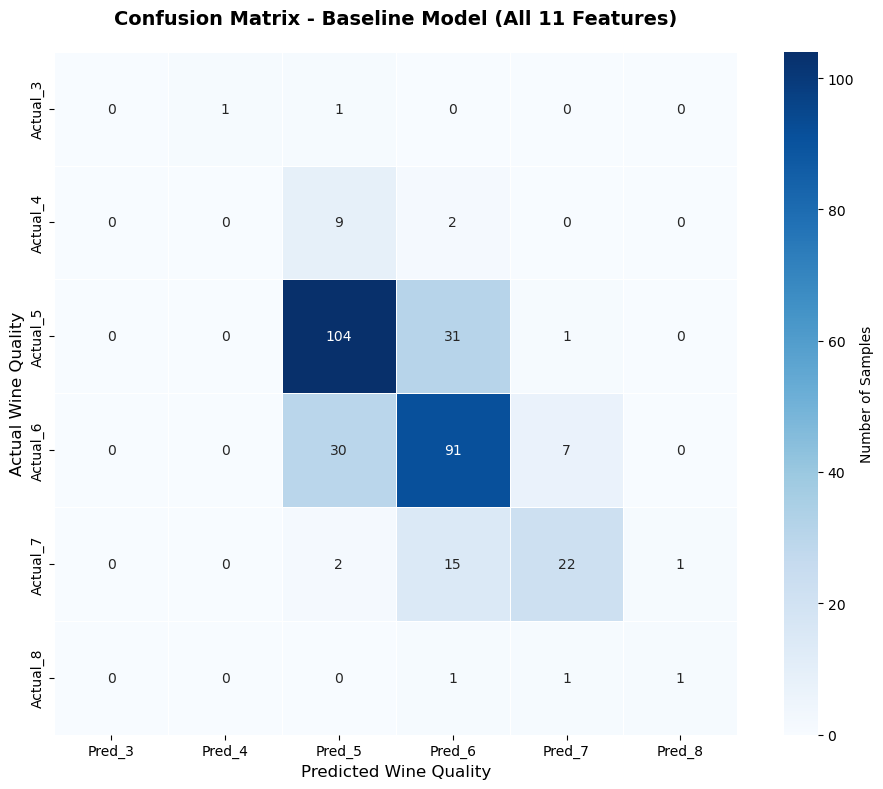


------------------------------------------------------------
4.7 CLASSIFICATION REPORT
------------------------------------------------------------

Detailed Classification Report (per quality class):
              precision    recall  f1-score   support

   Quality_3     0.0000    0.0000    0.0000         2
   Quality_4     0.0000    0.0000    0.0000        11
   Quality_5     0.7123    0.7647    0.7376       136
   Quality_6     0.6500    0.7109    0.6791       128
   Quality_7     0.7097    0.5500    0.6197        40
   Quality_8     0.5000    0.3333    0.4000         3

    accuracy                         0.6813       320
   macro avg     0.4287    0.3932    0.4061       320
weighted avg     0.6561    0.6813    0.6663       320


------------------------------------------------------------
4.8 CREATE TABLE 2 (BASELINE PERFORMANCE)
------------------------------------------------------------

TABLE 2: Baseline Performance Summary
                                 0
Model           

In [ ]:
# ============================================================
# 4. BASELINE MODEL (ALL FEATURES)
# ============================================================
# Train a baseline model using ALL 11 features
# This establishes our reference performance for comparison
# Géron: "First, train a quick-and-dirty model to get a baseline"

print("\n" + "="*60)
print("4. BASELINE MODEL (ALL FEATURES)")
print("="*60)

# ------------------------------------------------------------
# 4.1 MODEL SELECTION
# ------------------------------------------------------------
print("\n" + "-"*60)
print("4.1 MODEL SELECTION")
print("-"*60)

print("\nChosen Model: Random Forest Classifier")
print("Justification:")
print("  1. Robust to outliers (tree-based, not distance-based)")
print("  2. Handles non-linear relationships well")
print("  3. Provides built-in feature importance scores")
print("  4. No need for feature scaling (but we scaled anyway for consistency)")
print("  5. Works well with small-to-medium datasets (1599 samples)")
print("  6. Resistant to overfitting with proper hyperparameters")

# Update MODEL_PARAMS with full configuration
MODEL_PARAMS = {
    'n_estimators': 100,           # 100 decision trees in the forest
    'max_depth': None,             # Trees grow until leaves are pure or have min_samples_split
    'min_samples_split': 2,        # Minimum samples required to split an internal node
    'min_samples_leaf': 1,         # Minimum samples required at each leaf node
    'max_features': 'sqrt',        # Number of features to consider for best split (sqrt of total)
    'random_state': RANDOM_STATE,  # For reproducibility (42)
    'n_jobs': -1                   # Use all available CPU cores for parallel processing
}

print(f"\nModel Configuration:")
for param, value in MODEL_PARAMS.items():
    print(f"  - {param}: {value}")

# ------------------------------------------------------------
# 4.2 TRAIN BASELINE MODEL
# ------------------------------------------------------------
print("\n" + "-"*60)
print("4.2 TRAIN BASELINE MODEL")
print("-"*60)

print("\nInitializing Random Forest Classifier...")
baseline_model = RandomForestClassifier(**MODEL_PARAMS)
# **MODEL_PARAMS unpacks dictionary as keyword arguments
# Equivalent to: RandomForestClassifier(n_estimators=100, random_state=42, ...)

print(f"Training on {len(X_train_scaled)} samples with {len(X_train_scaled.columns)} features...")

# Record training time
import time
start_time = time.time()

# Train the model
baseline_model.fit(X_train_scaled, y_train)
# .fit() trains the Random Forest on training data
# X_train_scaled = scaled features (11 columns), y_train = target (quality scores)

training_time = time.time() - start_time
print(f"✓ Training completed in {training_time:.2f} seconds")

# ------------------------------------------------------------
# 4.3 MAKE PREDICTIONS
# ------------------------------------------------------------
print("\n" + "-"*60)
print("4.3 MAKE PREDICTIONS")
print("-"*60)

print("\nMaking predictions on test set...")
y_pred_baseline = baseline_model.predict(X_test_scaled)
# .predict() generates predicted quality scores for test data
# Returns array of predictions (one per test sample)

# Also get prediction probabilities (useful for some metrics)
y_pred_proba_baseline = baseline_model.predict_proba(X_test_scaled)
# .predict_proba() returns probability distribution across all quality classes
# Shape: (n_test_samples, n_quality_classes)

print(f"✓ Predictions generated for {len(X_test_scaled)} test samples")

# Quick preview of predictions vs actual
print("\nSample Predictions (first 10 test samples):")
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_baseline[:10],
    'Correct': (y_test.values[:10] == y_pred_baseline[:10])
})
print(comparison.to_string(index=False))

# ------------------------------------------------------------
# 4.4 EVALUATE PERFORMANCE
# ------------------------------------------------------------
print("\n" + "-"*60)
print("4.4 EVALUATE PERFORMANCE")
print("-"*60)

# Since wine quality is multi-class classification (scores 3-8),
# we need to specify 'weighted' average for precision, recall, F1
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score
)

# Calculate core performance metrics
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
# Accuracy = (number of correct predictions) / (total predictions)
# Simple but useful metric: what % of wines did we classify correctly?

baseline_precision = precision_score(y_test, y_pred_baseline, average='weighted', zero_division=0)
# Precision = TP / (TP + FP)
# "Of the wines we predicted as quality X, how many actually were quality X?"
# 'weighted' averages across all quality classes, weighted by number of samples

baseline_recall = recall_score(y_test, y_pred_baseline, average='weighted')
# Recall = TP / (TP + FN)
# "Of all wines that are actually quality X, how many did we correctly identify?"

baseline_f1 = f1_score(y_test, y_pred_baseline, average='weighted')
# F1-Score = 2 * (Precision * Recall) / (Precision + Recall)
# Harmonic mean balances precision and recall
# Good for imbalanced classes (we have more quality 5-6 wines than 3-4 or 7-8)

# Cohen's Kappa - good metric for ordinal data like wine quality scores
baseline_kappa = cohen_kappa_score(y_test, y_pred_baseline)
# Kappa accounts for agreement occurring by random chance
# Kappa = 1: perfect agreement, Kappa = 0: random agreement, Kappa < 0: worse than random

print("\n" + "="*60)
print("BASELINE MODEL PERFORMANCE")
print("="*60)

print(f"\nTest Set Metrics:")
print(f"  Accuracy:      {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"  Precision:     {baseline_precision:.4f}")
print(f"  Recall:        {baseline_recall:.4f}")
print(f"  F1-Score:      {baseline_f1:.4f}")
print(f"  Cohen's Kappa: {baseline_kappa:.4f}")

print(f"\nInterpretation:")
print(f"  - Model correctly predicts wine quality {baseline_accuracy*100:.1f}% of the time")
print(f"  - F1-Score of {baseline_f1:.4f} balances precision and recall")
if baseline_kappa > 0.8:
    kappa_level = "excellent"
elif baseline_kappa > 0.6:
    kappa_level = "substantial"
elif baseline_kappa > 0.4:
    kappa_level = "moderate"
else:
    kappa_level = "fair"
print(f"  - Kappa of {baseline_kappa:.4f} indicates {kappa_level} agreement beyond chance")

# ------------------------------------------------------------
# 4.5 CROSS-VALIDATION
# ------------------------------------------------------------
print("\n" + "-"*60)
print("4.5 CROSS-VALIDATION")
print("-"*60)

print(f"\nPerforming {CV_FOLDS}-Fold Cross-Validation on training set...")
print("(This validates model stability across different data splits...)")

# Perform k-fold cross-validation
cv_scores = cross_val_score(
    baseline_model,           # Model to evaluate
    X_train_scaled,          # Training features
    y_train,                 # Training labels
    cv=CV_FOLDS,            # Number of folds (5)
    scoring='accuracy',      # Metric to evaluate
    n_jobs=-1               # Use all CPU cores for parallel processing
)
# cross_val_score() splits training data into K folds
# Trains K times, each time using K-1 folds for training, 1 fold for validation
# Returns array of K accuracy scores (one per fold)

print(f"\n✓ Cross-validation completed")
print(f"\nCross-Validation Scores (accuracy per fold):")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f} ({score*100:.2f}%)")

cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

print(f"\nCross-Validation Summary:")
print(f"  Mean Accuracy: {cv_mean:.4f} (±{cv_std:.4f})")
print(f"  Min Accuracy:  {cv_scores.min():.4f}")
print(f"  Max Accuracy:  {cv_scores.max():.4f}")
print(f"  95% Confidence Interval: [{cv_mean - 2*cv_std:.4f}, {cv_mean + 2*cv_std:.4f}]")
# 95% CI approximated as mean ± 2*std (assumes normal distribution)

print(f"\nInterpretation:")
if cv_std < 0.05:
    print(f"  ✓ Low standard deviation ({cv_std:.4f}) indicates stable, consistent performance")
else:
    print(f"  ⚠ High standard deviation ({cv_std:.4f}) suggests performance varies across data splits")

# ------------------------------------------------------------
# 4.6 CONFUSION MATRIX
# ------------------------------------------------------------
print("\n" + "-"*60)
print("4.6 CONFUSION MATRIX")
print("-"*60)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)
# Confusion matrix shows actual quality vs predicted quality for each wine
# Rows = actual quality classes, Columns = predicted quality classes
# Diagonal = correct predictions, Off-diagonal = misclassifications

print("\nConfusion Matrix:")
print("(Rows = Actual Quality, Columns = Predicted Quality)")
print(cm)

# Create labeled confusion matrix DataFrame for better readability
quality_labels = sorted(y_test.unique())  # Get unique quality scores in test set
cm_df = pd.DataFrame(
    cm,
    index=[f'Actual_{q}' for q in quality_labels],
    columns=[f'Pred_{q}' for q in quality_labels]
)
print("\nLabeled Confusion Matrix:")
print(cm_df)

# Visualize confusion matrix as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_df, 
    annot=True,          # Show numbers in each cell
    fmt='d',             # Format as integers (not decimals)
    cmap='Blues',        # Blue color scheme (darker = more samples)
    cbar_kws={'label': 'Number of Samples'},
    square=True,         # Make cells square-shaped
    linewidths=0.5       # Add grid lines between cells
)
plt.title('Confusion Matrix - Baseline Model (All 11 Features)', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Actual Wine Quality', fontsize=12)
plt.xlabel('Predicted Wine Quality', fontsize=12)
plt.tight_layout()

# Create folder if doesn't exist
import os
os.makedirs('plots/02_baseline', exist_ok=True)

plt.savefig('plots/02_baseline/confusion_matrix_baseline.png', dpi=300, bbox_inches='tight')
print("\n✓ Confusion matrix visualization saved")
plt.show()

# ------------------------------------------------------------
# 4.7 CLASSIFICATION REPORT
# ------------------------------------------------------------
print("\n" + "-"*60)
print("4.7 CLASSIFICATION REPORT")
print("-"*60)

print("\nDetailed Classification Report (per quality class):")
print(classification_report(y_test, y_pred_baseline, 
                          target_names=[f'Quality_{q}' for q in quality_labels],
                          digits=4))
# classification_report() shows precision, recall, f1-score for EACH quality class
# 'support' column shows number of test samples in each class
# Helps identify which quality scores are harder to predict

# ------------------------------------------------------------
# 4.8 CREATE TABLE 2 FOR PAPER
# ------------------------------------------------------------
print("\n" + "-"*60)
print("4.8 CREATE TABLE 2 (BASELINE PERFORMANCE)")
print("-"*60)

# Store baseline metrics in DataFrame - this is TABLE 2 for your paper!
baseline_metrics = {
    'Model': 'Random Forest',
    'Features_Used': 'All 11 features',
    'Num_Features': 11,
    'Train_Samples': len(X_train_scaled),
    'Test_Samples': len(X_test_scaled),
    'Accuracy': baseline_accuracy,
    'Precision': baseline_precision,
    'Recall': baseline_recall,
    'F1_Score': baseline_f1,
    'Cohen_Kappa': baseline_kappa,
    'CV_Mean': cv_mean,
    'CV_Std': cv_std,
    'Training_Time_sec': training_time
}

baseline_df = pd.DataFrame([baseline_metrics])

print("\n" + "="*60)
print("TABLE 2: Baseline Performance Summary")
print("="*60)
print(baseline_df.T.to_string())  # .T transposes for vertical display (better readability)

# Save as CSV
baseline_df.to_csv('results/table2_baseline_performance.csv', index=False)
print("\n✓ Table 2 saved as 'table2_baseline_performance.csv'")

# ============================================================
# BASELINE MODEL COMPLETED
# ============================================================
print("\n" + "="*60)
print("BASELINE MODEL TRAINING COMPLETED ✓")
print("="*60)

print("\nKEY INSIGHTS:")
print(f"1. Baseline Accuracy: {baseline_accuracy:.4f} ({baseline_accuracy*100:.1f}%)")
print(f"2. Cross-Validation: {cv_mean:.4f} ± {cv_std:.4f}")
print(f"3. F1-Score: {baseline_f1:.4f}")
print(f"4. Cohen's Kappa: {baseline_kappa:.4f}")
print(f"5. Training Time: {training_time:.2f} seconds")

print("\n🎯 Performance Benchmark Established!")
print(f"   All feature selection and ablation experiments will be")
print(f"   compared against this baseline accuracy of {baseline_accuracy:.4f}")

print("\nFiles Created:")
print("  ✓ results/table2_baseline_performance.csv")
print("  ✓ plots/02_baseline/confusion_matrix_baseline.png")

# Store baseline metrics globally for later comparison
BASELINE_ACCURACY = baseline_accuracy
BASELINE_F1 = baseline_f1
BASELINE_PRECISION = baseline_precision
BASELINE_RECALL = baseline_recall


In [549]:
# -------- 4. BASELINE MODEL (ALL FEATURES) --------
# Train baseline with all features
# Evaluate performance
# Store baseline metrics


In [550]:
# -------- 5. FEATURE SELECTION METHODS --------
# 5.1 Filter Methods
# - Correlation
# - Mutual Information
# - Statistical tests
# 5.2 Wrapper Methods
# - RFE
# - Forward/Backward Selection
# 5.3 Embedded Methods
# - Model-based importance
# - L1 regularization


In [551]:
# -------- 6. ABLATION STUDY --------
# 6.1 Individual Feature Ablation
# For each feature:
# - Remove feature
# - Train model
# - Measure performance drop
# - Store results
# 6.2 Cumulative Feature Addition
# Start with empty set
# Add features one by one (by importance)
# Track performance
# 6.3 Top-K Feature Selection
# Try k = 3, 5, 7, 10, etc.
# Compare performance


In [552]:
# -------- 7. VISUALIZATIONS --------
# - Feature importance comparison
# - Ablation results
# - Performance vs. feature count
# - Correlation heatmap


In [553]:
# -------- 8. STATISTICAL ANALYSIS --------
# Compare feature subsets
# Significance testing


In [554]:
# -------- 9. RESULTS EXPORT --------
# Save figures
# Export results tables
